# 03 - Auditoría XAI: SHAP, modelo subrogado y contrafactuales

Este notebook explica modelos que, por construcción, no son transparentes:

- Red neuronal MLP.
- Política neuronal de contextual bandit.

La auditoría se organiza en tres niveles:

1. **Explicación global**: qué variables son importantes en promedio.
2. **Explicación local**: por qué un cliente concreto recibe una predicción.
3. **Contrafactuales**: qué tendría que cambiar para modificar la decisión.

También se entrena un **modelo subrogado** interpretable: un árbol de decisión pequeño que intenta imitar las decisiones del modelo caja negra. Esto permite extraer reglas aproximadas.

In [1]:
# ==============================
# Imports
# ==============================

from __future__ import annotations

import json
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_AVAILABLE = False
    print("SHAP no está disponible. Se usará importancia por permutación como fallback.")
    print(exc)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUTPUT_DIR = Path("outputs")
OBJECTS_DIR = OUTPUT_DIR / "objects"
MODELS_DIR = OUTPUT_DIR / "models"
XAI_DIR = OUTPUT_DIR / "xai"
XAI_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Device: cpu


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de datos, modelos y metadatos

Este notebook requiere haber ejecutado:

1. `01_EDA_Preprocesado.ipynb`
2. `02_Modelado_RL_NN.ipynb`

Se cargan los modelos finales y se reconstruyen las clases PyTorch con la misma arquitectura usada durante entrenamiento.

In [2]:
required_files = [
    OUTPUT_DIR / "preprocessed_train.csv",
    OBJECTS_DIR / "preprocessing_objects.joblib",
    OBJECTS_DIR / "final_model_scaler.joblib",
    MODELS_DIR / "model_metadata.joblib",
]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Falta {path}. Ejecuta primero los notebooks 01 y 02.")

train_df = pd.read_csv(OUTPUT_DIR / "preprocessed_train.csv")
preprocessing_objects = joblib.load(OBJECTS_DIR / "preprocessing_objects.joblib")
scaler = joblib.load(OBJECTS_DIR / "final_model_scaler.joblib")
model_metadata = joblib.load(MODELS_DIR / "model_metadata.joblib")

TARGET = preprocessing_objects["target"]
FEATURES = preprocessing_objects["final_features"]

X = train_df[FEATURES].astype(float)
y = train_df[TARGET].astype(int)
X_scaled = scaler.transform(X)

print("Datos:", X.shape)
print("Modelos seleccionados:")
print(json.dumps(model_metadata["selected_models"], indent=2))

Datos: (104669, 16)
Modelos seleccionados:
{
  "cost_1_1": {
    "model_family": "MLP",
    "model_file": "final_mlp.pt",
    "threshold": 0.9226868686868686
  },
  "cost_1_10": {
    "model_family": "MLP",
    "model_file": "final_mlp.pt",
    "threshold": 0.5554343434343434
  }
}


In [3]:
class CreditMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64, 32), dropout: float = 0.25):
        super().__init__()
        h1, h2, h3 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class ContextualBanditPolicy(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), dropout: float = 0.20):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.BatchNorm1d(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, 2),
        )

    def forward(self, x):
        return self.net(x)


# Familias de modelo reconocidas. "ContextualBanditPolicy_IPS" usa la misma
# arquitectura que "ContextualBanditPolicy" (el bandit de información
# completa) -- lo único que cambió entre ellos fue CÓMO se entrenaron en el
# notebook 02, no la arquitectura de la red. Por eso comparten clase aquí.
BANDIT_FAMILIES = {"ContextualBanditPolicy", "ContextualBanditPolicy_IPS"}


def load_torch_model(model_path: Path):
    """Carga un modelo PyTorch guardado en el notebook 02."""
    checkpoint = torch.load(model_path, map_location=DEVICE)
    model_type = checkpoint["model_type"]

    if model_type == "MLP":
        model = CreditMLP(
            input_dim=checkpoint["input_dim"],
            hidden_dims=tuple(checkpoint["hidden_dims"]),
            dropout=checkpoint["dropout"],
        )
    elif model_type in BANDIT_FAMILIES:
        # Ambas variantes de bandit (información completa e IPS) comparten
        # arquitectura: ContextualBanditPolicy.
        model = ContextualBanditPolicy(
            input_dim=checkpoint["input_dim"],
            hidden_dims=tuple(checkpoint["hidden_dims"]),
            dropout=checkpoint["dropout"],
        )
    else:
        raise ValueError(
            f"Tipo de modelo no reconocido: {model_type!r}. "
            f"Tipos soportados: 'MLP', {sorted(BANDIT_FAMILIES)}."
        )

    model.load_state_dict(checkpoint["state_dict"])
    model.to(DEVICE)
    model.eval()
    return model, checkpoint


def predict_model_score(model, model_family: str, X_array: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """
    Devuelve score comparable a probabilidad de clase 1.

    - MLP: sigmoid(logit).
    - Bandit (información completa o IPS): probabilidad de acción 1 por softmax.
      Las dos variantes de bandit comparten arquitectura y forma de scorear;
      lo que cambió fue cómo se entrenaron, no cómo se leen sus salidas.
    """
    scores = []
    with torch.no_grad():
        for start in range(0, len(X_array), batch_size):
            xb = torch.tensor(X_array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            if model_family == "MLP":
                score = torch.sigmoid(model(xb)).cpu().numpy()
            elif model_family in BANDIT_FAMILIES:
                score = F.softmax(model(xb), dim=1)[:, 1].cpu().numpy()
            else:
                raise ValueError(
                    f"model_family no reconocida: {model_family!r}. "
                    f"Soportadas: 'MLP', {sorted(BANDIT_FAMILIES)}."
                )
            scores.append(score)
    return np.concatenate(scores)


def predict_selected_scenario(scenario: str, X_raw: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """Predice score y clase para el modelo seleccionado de un escenario."""
    selected = model_metadata["selected_models"][scenario]
    model_path = MODELS_DIR / selected["model_file"]
    model, checkpoint = load_torch_model(model_path)
    X_arr = scaler.transform(X_raw[FEATURES].astype(float))
    score = predict_model_score(model, selected["model_family"], X_arr)
    pred = (score >= selected["threshold"]).astype(int)
    return score, pred, selected


In [4]:
# Calculamos predicciones para ambos escenarios.
scenario_predictions = {}
for scenario in model_metadata["scenarios"].keys():
    score, pred, selected = predict_selected_scenario(scenario, X)
    scenario_predictions[scenario] = {"score": score, "pred": pred, "selected": selected}
    print("\nEscenario:", scenario)
    print("Modelo:", selected)
    print("AUC aproximado:", roc_auc_score(y, score))
    display(pd.DataFrame(confusion_matrix(y, pred, labels=[0, 1]), index=["real_0", "real_1"], columns=["pred_0", "pred_1"]))


Escenario: cost_1_1
Modelo: {'model_family': 'MLP', 'model_file': 'final_mlp.pt', 'threshold': 0.9226868686868686}
AUC aproximado: 0.8420406018128997


,pred_0,pred_1
real_0,96488,1166
real_1,5452,1563



Escenario: cost_1_10
Modelo: {'model_family': 'MLP', 'model_file': 'final_mlp.pt', 'threshold': 0.5554343434343434}
AUC aproximado: 0.8420406018128997


,pred_0,pred_1
real_0,82282,15372
real_1,2172,4843


## 2. Selección del modelo a auditar

Auditaremos principalmente el escenario `cost_1_10`, porque es el más sensible desde el punto de vista de riesgo: equivocarse concediendo crédito a un cliente que acaba en mora grave cuesta diez veces más que rechazar a un cliente bueno.

Aun así, el código permite cambiar `AUDIT_SCENARIO` a `cost_1_1`.

In [5]:
AUDIT_SCENARIO = "cost_1_10"

audit_score = scenario_predictions[AUDIT_SCENARIO]["score"]
audit_pred = scenario_predictions[AUDIT_SCENARIO]["pred"]
audit_selected = scenario_predictions[AUDIT_SCENARIO]["selected"]

audit_model, audit_checkpoint = load_torch_model(MODELS_DIR / audit_selected["model_file"])
audit_family = audit_selected["model_family"]
audit_threshold = audit_selected["threshold"]

print("Escenario auditado:", AUDIT_SCENARIO)
print("Modelo auditado:", audit_selected)

Escenario auditado: cost_1_10
Modelo auditado: {'model_family': 'MLP', 'model_file': 'final_mlp.pt', 'threshold': 0.5554343434343434}


## 3. Modelo subrogado interpretable

Un modelo subrogado intenta imitar el comportamiento del modelo caja negra, no el target real directamente.

Aquí entrenamos un árbol de decisión pequeño con `max_depth=3` para aproximar las decisiones del modelo auditado. El objetivo es extraer reglas sencillas del tipo:

> Si el número de retrasos de 90 días es alto y la utilización de crédito es alta, entonces el modelo tiende a clasificar como alto riesgo.

La métrica importante del subrogado es la **fidelidad**, es decir, cuánto coincide con la caja negra.

In [6]:
# Dividimos para medir fidelidad fuera de la muestra usada por el subrogado.
X_sur_train, X_sur_test, y_sur_train, y_sur_test = train_test_split(
    X,
    audit_pred,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=audit_pred,
)

surrogate_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=300,
    random_state=RANDOM_STATE,
)
surrogate_tree.fit(X_sur_train, y_sur_train)

sur_pred = surrogate_tree.predict(X_sur_test)
fidelity = accuracy_score(y_sur_test, sur_pred)

print("Fidelidad del árbol subrogado respecto al modelo caja negra:", round(fidelity, 4))
print(classification_report(y_sur_test, sur_pred, digits=4, zero_division=0))

Fidelidad del árbol subrogado respecto al modelo caja negra: 0.9492
              precision    recall  f1-score   support

           0     0.9543    0.9841    0.9690     21114
           1     0.9236    0.8033    0.8593      5054

    accuracy                         0.9492     26168
   macro avg     0.9390    0.8937    0.9141     26168
weighted avg     0.9484    0.9492    0.9478     26168



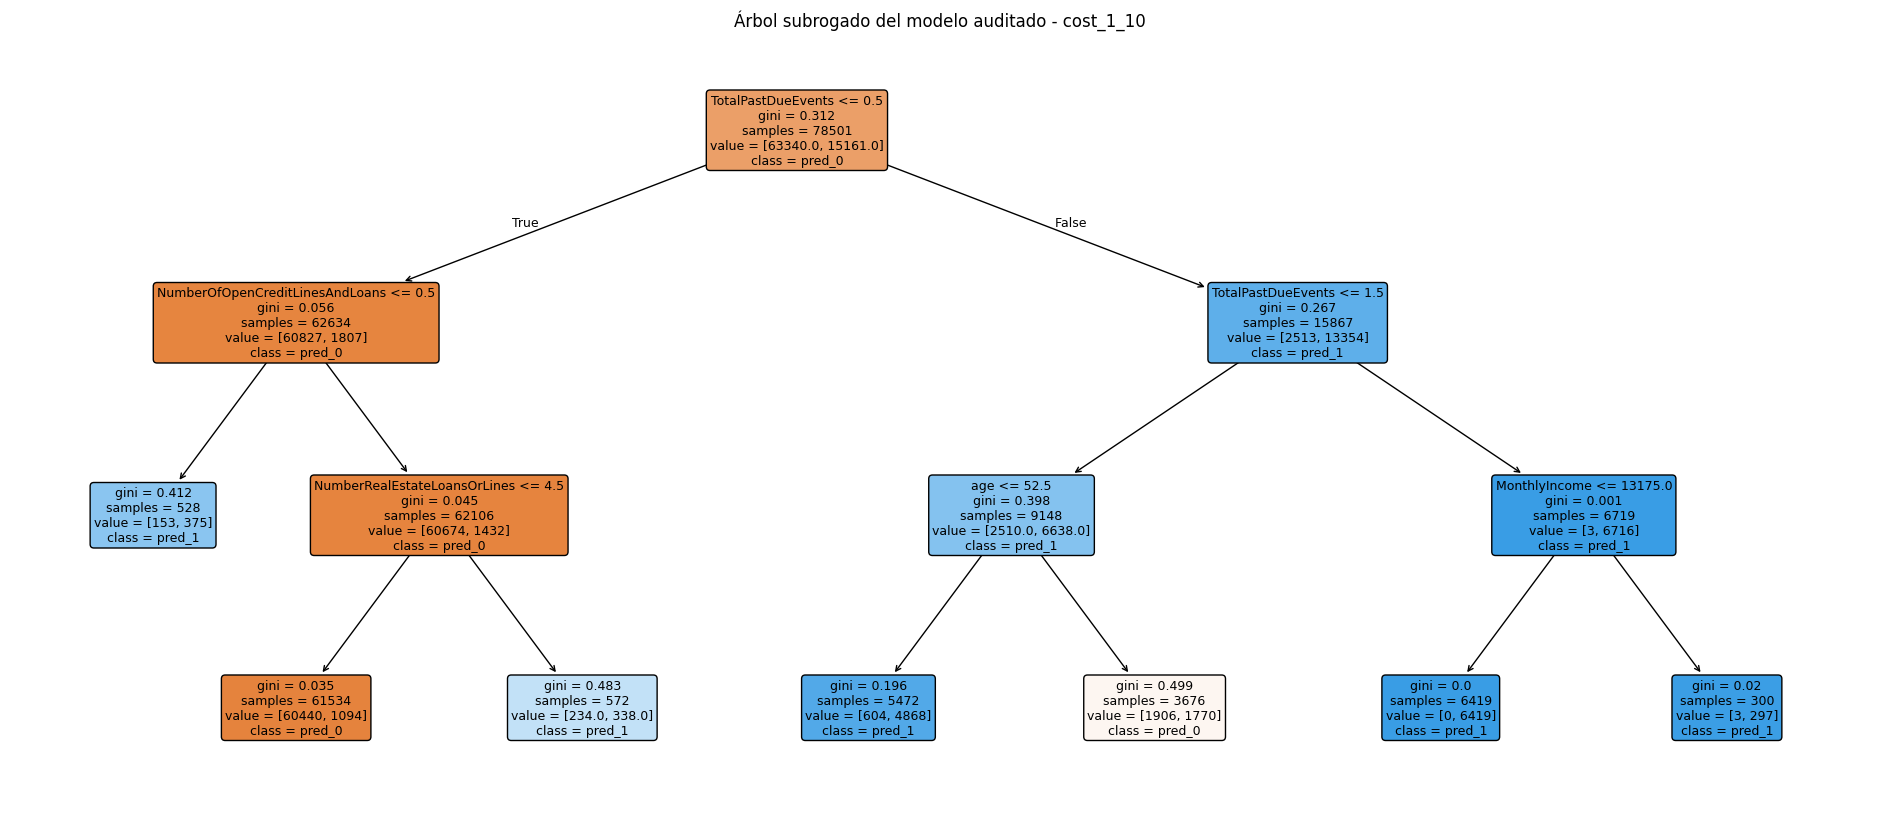

In [7]:
plt.figure(figsize=(24, 10))
plot_tree(
    surrogate_tree,
    feature_names=FEATURES,
    class_names=["pred_0", "pred_1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title(f"Árbol subrogado del modelo auditado - {AUDIT_SCENARIO}")
plt.show()

In [8]:
rules_text = export_text(surrogate_tree, feature_names=FEATURES, decimals=3)
print(rules_text)

with open(XAI_DIR / f"surrogate_rules_{AUDIT_SCENARIO}.txt", "w", encoding="utf-8") as f:
    f.write(rules_text)

print("Reglas guardadas en:", XAI_DIR / f"surrogate_rules_{AUDIT_SCENARIO}.txt")

|--- TotalPastDueEvents <= 0.500
|   |--- NumberOfOpenCreditLinesAndLoans <= 0.500
|   |   |--- class: 1
|   |--- NumberOfOpenCreditLinesAndLoans >  0.500
|   |   |--- NumberRealEstateLoansOrLines <= 4.500
|   |   |   |--- class: 0
|   |   |--- NumberRealEstateLoansOrLines >  4.500
|   |   |   |--- class: 1
|--- TotalPastDueEvents >  0.500
|   |--- TotalPastDueEvents <= 1.500
|   |   |--- age <= 52.500
|   |   |   |--- class: 1
|   |   |--- age >  52.500
|   |   |   |--- class: 0
|   |--- TotalPastDueEvents >  1.500
|   |   |--- MonthlyIncome <= 13175.000
|   |   |   |--- class: 1
|   |   |--- MonthlyIncome >  13175.000
|   |   |   |--- class: 1

Reglas guardadas en: outputs/xai/surrogate_rules_cost_1_10.txt


## 4. Importancia global por permutación

La importancia por permutación mide cuánto empeora el modelo si rompemos aleatoriamente una variable. Si al permutar una variable el score del modelo empeora mucho, significa que el modelo dependía bastante de esa variable.

Para evitar tiempos excesivos, usamos una muestra.

In [9]:
class BlackBoxWrapper(ClassifierMixin, BaseEstimator):
    """
    Wrapper estilo sklearn para poder usar permutation_importance.

    Hereda de BaseEstimator/ClassifierMixin porque sklearn >= 1.3 valida
    internamente "tags" del estimador (__sklearn_tags__) antes de calcular
    la importancia por permutación; sin esa herencia, la validación falla
    aunque el wrapper funcione perfectamente bien.
    """
    def __init__(self, model, model_family: str, threshold: float):
        self.model = model
        self.model_family = model_family
        self.threshold = threshold
        # sklearn exige que un clasificador exponga classes_ (aunque nunca
        # se llame a fit de verdad, ya que el modelo ya viene entrenado).
        self.classes_ = np.array([0, 1])

    def fit(self, X_input=None, y_input=None):
        # No-op: el modelo ya viene entrenado desde el notebook 02.
        # sklearn >= 1.3 exige que permutation_importance reciba un
        # estimador con método fit (aunque nunca llegue a invocarlo),
        # así que lo añadimos solo para pasar esa validación.
        return self

    def predict_proba(self, X_input):
        if isinstance(X_input, pd.DataFrame):
            X_arr = scaler.transform(X_input[FEATURES].astype(float))
        else:
            X_arr = scaler.transform(pd.DataFrame(X_input, columns=FEATURES).astype(float))
        score = predict_model_score(self.model, self.model_family, X_arr)
        return np.vstack([1 - score, score]).T

    def predict(self, X_input):
        return (self.predict_proba(X_input)[:, 1] >= self.threshold).astype(int)

    def score(self, X_input, y_input):
        return roc_auc_score(y_input, self.predict_proba(X_input)[:, 1])


blackbox = BlackBoxWrapper(audit_model, audit_family, audit_threshold)

perm_sample_idx = X.sample(n=min(8000, len(X)), random_state=RANDOM_STATE).index
X_perm = X.loc[perm_sample_idx]
y_perm = y.loc[perm_sample_idx]

perm = permutation_importance(
    blackbox,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

perm_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_importance.head(20)

,feature,importance_mean,importance_std
1,age,0.0330,0.0047
2,NumberOfTime30-59DaysPastDueNotWorse,0.0266,0.0033
6,NumberOfTimes90DaysLate,0.0225,0.0022
14,TotalPastDueEvents,0.0189,0.0022
8,NumberOfTime60-89DaysPastDueNotWorse,0.0145,0.0001
5,NumberOfOpenCreditLinesAndLoans,0.0118,0.0014
15,CreditLinesPerRealEstateLoan,0.0110,0.0018
4,MonthlyIncome,0.0091,0.0017
7,NumberRealEstateLoansOrLines,0.0088,0.0013
11,MonthlyIncome_was_missing,0.0050,0.0005


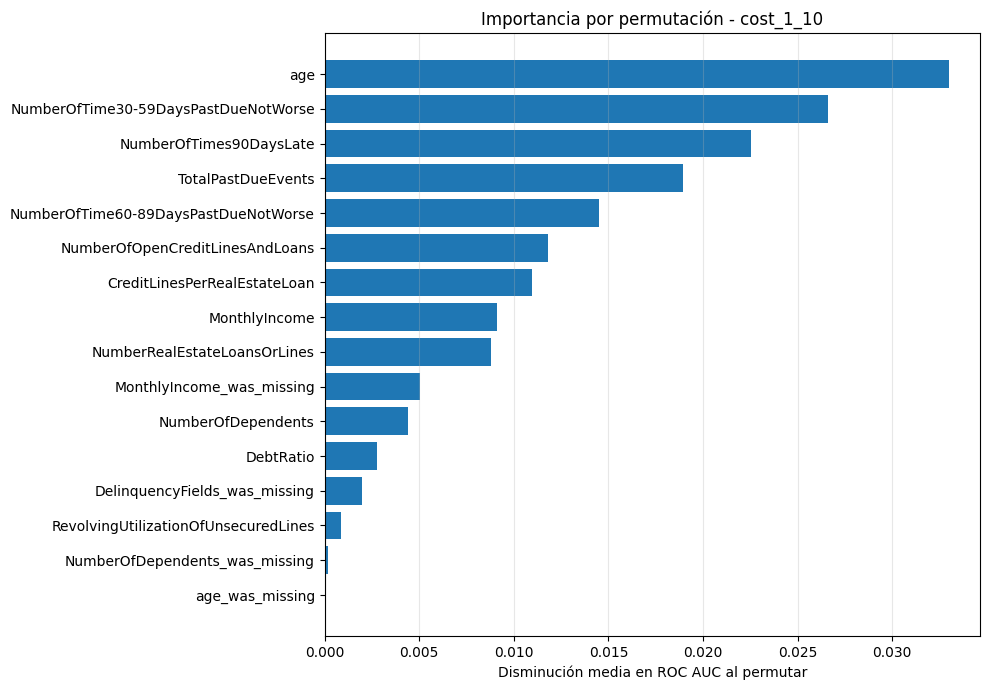

In [10]:
plt.figure(figsize=(10, 7))
top_perm = perm_importance.head(20).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"Importancia por permutación - {AUDIT_SCENARIO}")
plt.xlabel("Disminución media en ROC AUC al permutar")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

perm_importance.to_csv(XAI_DIR / f"permutation_importance_{AUDIT_SCENARIO}.csv", index=False)

## 5. SHAP global y local

SHAP descompone la predicción en aportaciones por variable. Para modelos neuronales tabulares, `KernelExplainer` es más general pero más lento. Por eso usamos muestras pequeñas:

- `background`: muestra usada como referencia.
- `explain_sample`: clientes concretos que explicamos.

Si el equipo tiene poco tiempo de cómputo, se puede reducir el tamaño de las muestras.

In [11]:
# Función que SHAP puede llamar: recibe datos en escala original y devuelve probabilidad de clase 1.
def shap_predict_proba(x_numpy: np.ndarray) -> np.ndarray:
    x_df = pd.DataFrame(x_numpy, columns=FEATURES)
    x_scaled = scaler.transform(x_df.astype(float))
    return predict_model_score(audit_model, audit_family, x_scaled)

# Muestras para SHAP.
background = X.sample(n=min(100, len(X)), random_state=RANDOM_STATE)
explain_sample = X.sample(n=min(300, len(X)), random_state=RANDOM_STATE + 1)

print("Background SHAP:", background.shape)
print("Muestra a explicar:", explain_sample.shape)

Background SHAP: (100, 16)
Muestra a explicar: (300, 16)


In [12]:
if SHAP_AVAILABLE:
    # KernelExplainer es lento pero válido para cualquier caja negra.
    explainer = shap.KernelExplainer(shap_predict_proba, background)
    shap_values = explainer.shap_values(explain_sample, nsamples=100)

    # En algunas versiones shap_values puede venir como lista; normalizamos.
    if isinstance(shap_values, list):
        shap_values_array = shap_values[0]
    else:
        shap_values_array = shap_values

    print("SHAP values shape:", np.array(shap_values_array).shape)
else:
    shap_values_array = None

  0%|          | 0/300 [00:00<?, ?it/s]

  2%|▏         | 7/300 [00:00<00:04, 64.88it/s]

  5%|▍         | 14/300 [00:00<00:04, 64.47it/s]

  7%|▋         | 21/300 [00:00<00:04, 66.04it/s]

  9%|▉         | 28/300 [00:00<00:04, 65.65it/s]

...

 94%|█████████▎| 281/300 [00:04<00:00, 61.40it/s]

 96%|█████████▌| 288/300 [00:04<00:00, 61.57it/s]

 98%|█████████▊| 295/300 [00:04<00:00, 60.89it/s]

100%|██████████| 300/300 [00:04<00:00, 63.97it/s]

SHAP values shape: (300, 16)


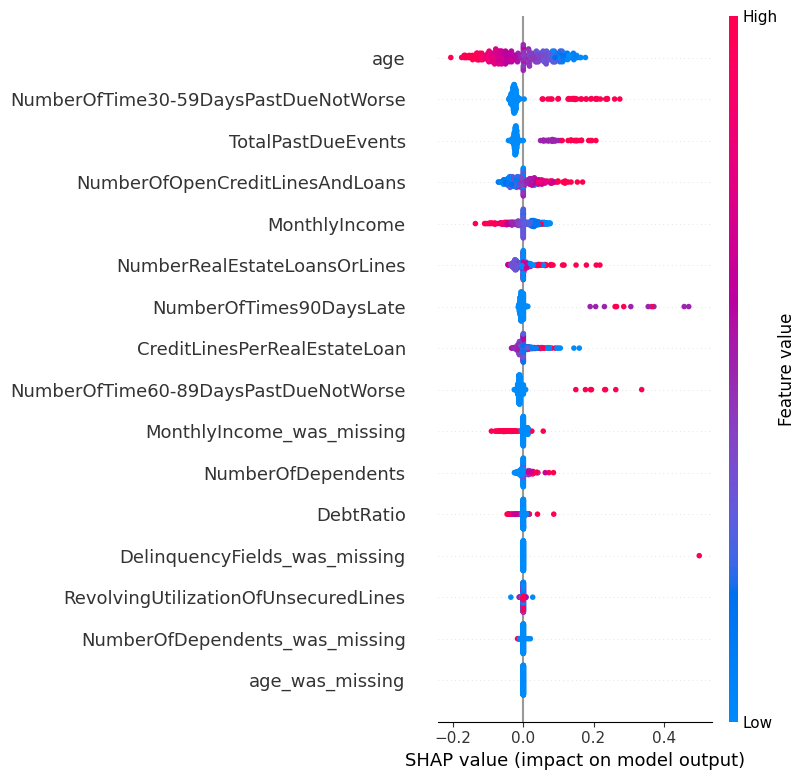

In [13]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap.summary_plot(shap_values_array, explain_sample, feature_names=FEATURES, show=True)

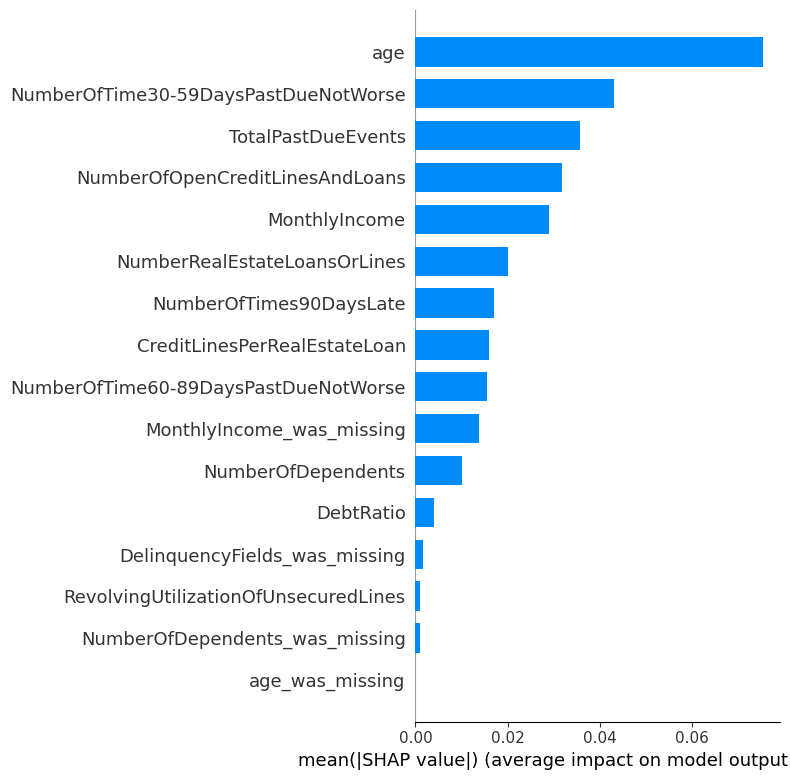

In [14]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap.summary_plot(shap_values_array, explain_sample, feature_names=FEATURES, plot_type="bar", show=True)

In [15]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap_global = pd.DataFrame({
        "feature": FEATURES,
        "mean_abs_shap": np.abs(shap_values_array).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    display(shap_global.head(20))
    shap_global.to_csv(XAI_DIR / f"shap_global_{AUDIT_SCENARIO}.csv", index=False)
else:
    shap_global = perm_importance.rename(columns={"importance_mean": "mean_abs_shap"})[["feature", "mean_abs_shap"]]

,feature,mean_abs_shap
1,age,0.0752
2,NumberOfTime30-59DaysPastDueNotWorse,0.0430
14,TotalPastDueEvents,0.0356
5,NumberOfOpenCreditLinesAndLoans,0.0318
4,MonthlyIncome,0.0289
7,NumberRealEstateLoansOrLines,0.0200
6,NumberOfTimes90DaysLate,0.0169
15,CreditLinesPerRealEstateLoan,0.0158
8,NumberOfTime60-89DaysPastDueNotWorse,0.0155
11,MonthlyIncome_was_missing,0.0138


### 5.1 Explicaciones locales

Antes se cogían solo los casos más "claros" de cada clase (score más alto en
cada grupo). Aquí mezclamos varios tipos de caso, porque cada uno enseña algo
distinto:

- **Clase 0, score alto** (2 casos): buenos pagadores a los que el modelo ve
  como arriesgados — posibles falsos positivos, interesante para ver si el
  modelo es "injusto" en algún perfil concreto.
- **Clase 1, score alto** (2 casos): morosos reales que el modelo detecta con
  claridad — casos donde el modelo acierta y es fácil de explicar.
- **Clase 1, score bajo** (2 casos): morosos reales que el modelo **no**
  detecta — falsos negativos. Son el error más caro en el escenario
  `FP=1, FN=10`, así que merece la pena ver qué tienen en común los casos que
  se le escapan al modelo.
- **Casos límite** (2 casos, de cualquier clase real): los que tienen el
  score más cercano al threshold de decisión — son los más útiles para
  contrafactuales, porque necesitan pocos cambios para cruzar la frontera.

Esto sirve para responder a preguntas del tipo:

> ¿Por qué se me ha denegado el crédito?

pero también para auditar honestamente dónde falla el modelo, no solo
enseñar sus aciertos.


In [16]:
# Elegimos ejemplos reales de cada clase, mezclando casos claros y casos
# límite/fallos (en vez de solo los casos más "obvios").
examples_0 = train_df[y == 0].copy()
examples_1 = train_df[y == 1].copy()

examples_0["score"] = audit_score[y == 0]
examples_1["score"] = audit_score[y == 1]

# 1) Clase 0 con score alto: buenos pagadores que el modelo ve como
#    arriesgados -> posibles falsos positivos.
case_class0_high = examples_0.sort_values("score", ascending=False).head(2).copy()
case_class0_high["case_type"] = "clase_0_score_alto (posible falso positivo)"

# 2) Clase 1 con score alto: morosos reales detectados con claridad.
case_class1_high = examples_1.sort_values("score", ascending=False).head(2).copy()
case_class1_high["case_type"] = "clase_1_score_alto (acierto claro)"

# 3) Clase 1 con score bajo: morosos reales que el modelo NO detecta
#    -> falsos negativos, el error más caro en el escenario FP=1,FN=10.
case_class1_low = examples_1.sort_values("score", ascending=True).head(2).copy()
case_class1_low["case_type"] = "clase_1_score_bajo (falso negativo)"

# 4) Casos límite: score más cercano al threshold de decisión, de cualquier
#    clase real -> los más útiles para contrafactuales (pocos cambios
#    necesarios para cruzar la frontera).
all_examples = pd.concat([examples_0, examples_1])
all_examples["dist_to_threshold"] = (all_examples["score"] - audit_threshold).abs()
case_borderline = all_examples.sort_values("dist_to_threshold", ascending=True).head(2).copy()
case_borderline["case_type"] = "caso_limite (cerca del threshold)"

local_cases_df = pd.concat([
    case_class0_high, case_class1_high, case_class1_low, case_borderline
])

local_indices = local_cases_df.index.tolist()
local_cases = X.loc[local_indices].copy()
local_scores = audit_score[local_indices]
local_preds = audit_pred[local_indices]
local_true = y.loc[local_indices].values

local_summary = pd.DataFrame({
    "index": local_indices,
    "case_type": local_cases_df["case_type"].values,
    "true_class": local_true,
    "model_score_class_1": local_scores,
    "model_prediction": local_preds,
})
local_summary


,index,case_type,true_class,model_score_class_1,model_prediction
0,82498,clase_0_score_alto (posible falso positivo),0,1.0000,1
1,52431,clase_0_score_alto (posible falso positivo),0,0.9997,1
2,53957,clase_1_score_alto (acierto claro),1,0.9999,1
3,43161,clase_1_score_alto (acierto claro),1,0.9999,1
4,45559,clase_1_score_bajo (falso negativo),1,0.0338,0
5,26131,clase_1_score_bajo (falso negativo),1,0.0458,0
6,2845,caso_limite (cerca del threshold),0,0.5554,1
7,54596,caso_limite (cerca del threshold),0,0.5554,0


In [17]:
if SHAP_AVAILABLE:
    local_shap_values = explainer.shap_values(local_cases, nsamples=200)
    if isinstance(local_shap_values, list):
        local_shap_values = local_shap_values[0]

    for i, idx in enumerate(local_indices):
        print("\nCaso index:", idx, "| real:", local_true[i], "| pred:", local_preds[i], "| score:", round(local_scores[i], 4))
        contrib = pd.DataFrame({
            "feature": FEATURES,
            "value": local_cases.iloc[i].values,
            "shap_value": local_shap_values[i],
            "abs_shap": np.abs(local_shap_values[i]),
        }).sort_values("abs_shap", ascending=False)
        display(contrib.head(10))
else:
    print("SHAP no disponible; usa la importancia por permutación y el subrogado para explicación global/local.")

  0%|          | 0/8 [00:00<?, ?it/s]

 50%|█████     | 4/8 [00:00<00:00, 38.62it/s]

100%|██████████| 8/8 [00:00<00:00, 39.87it/s]


Caso index: 82498 | real: 0 | pred: 1 | score: 1.0


,feature,value,shap_value,abs_shap
6,NumberOfTimes90DaysLate,6.0000,0.1668,0.1668
8,NumberOfTime60-89DaysPastDueNotWorse,8.0000,0.1626,0.1626
14,TotalPastDueEvents,19.0000,0.1500,0.1500
7,NumberRealEstateLoansOrLines,14.0000,0.1442,0.1442
2,NumberOfTime30-59DaysPastDueNotWorse,5.0000,0.0526,0.0526
9,NumberOfDependents,0.0000,-0.0375,0.0375
1,age,59.0000,0.0351,0.0351
12,NumberOfDependents_was_missing,0.0000,-0.0185,0.0185
11,MonthlyIncome_was_missing,0.0000,0.0159,0.0159
15,CreditLinesPerRealEstateLoan,2.2667,0.0028,0.0028


...

,feature,value,shap_value,abs_shap
1,age,78.0000,-0.1235,0.1235
11,MonthlyIncome_was_missing,1.0000,-0.0356,0.0356
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,-0.0295,0.0295
14,TotalPastDueEvents,0.0000,-0.0270,0.0270
5,NumberOfOpenCreditLinesAndLoans,2.0000,-0.0194,0.0194
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,-0.0139,0.0139
12,NumberOfDependents_was_missing,1.0000,-0.0137,0.0137
4,MonthlyIncome,"6,643.6274",-0.0069,0.0069
6,NumberOfTimes90DaysLate,0.0000,-0.0058,0.0058
9,NumberOfDependents,0.0000,-0.0048,0.0048



Caso index: 2845 | real: 0 | pred: 1 | score: 0.5554


,feature,value,shap_value,abs_shap
7,NumberRealEstateLoansOrLines,4.0000,0.1614,0.1614
1,age,43.0000,0.0844,0.0844
5,NumberOfOpenCreditLinesAndLoans,6.0000,-0.0358,0.0358
4,MonthlyIncome,"3,797.0000",0.0312,0.0312
15,CreditLinesPerRealEstateLoan,1.2000,0.0296,0.0296
14,TotalPastDueEvents,0.0000,-0.0203,0.0203
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,-0.0203,0.0203
11,MonthlyIncome_was_missing,0.0000,0.0119,0.0119
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,-0.0073,0.0073
6,NumberOfTimes90DaysLate,0.0000,-0.0052,0.0052



Caso index: 54596 | real: 0 | pred: 0 | score: 0.5554


,feature,value,shap_value,abs_shap
5,NumberOfOpenCreditLinesAndLoans,23.0000,0.1293,0.1293
7,NumberRealEstateLoansOrLines,3.0000,0.0604,0.0604
1,age,50.0000,0.0363,0.0363
4,MonthlyIncome,"3,877.0000",0.0267,0.0267
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,-0.0207,0.0207
14,TotalPastDueEvents,0.0000,-0.0175,0.0175
9,NumberOfDependents,1.0000,0.0174,0.0174
15,CreditLinesPerRealEstateLoan,5.7500,-0.0161,0.0161
11,MonthlyIncome_was_missing,0.0000,0.0098,0.0098
3,DebtRatio,0.6034,0.0039,0.0039


## 6. Contrafactuales

Un contrafactual responde:

> ¿Qué tendría que cambiar para que el modelo cambiara su decisión?

Ejemplo: si el modelo deniega crédito, buscamos cambios razonables que hagan que pase a aprobarlo.

Implementamos una búsqueda sencilla y transparente:

1. Tomamos un cliente concreto.
2. Modificamos una variable cada vez hacia valores percentiles observados en construcción.
3. Probamos combinaciones greedy de cambios.
4. Devolvemos el primer caso que cruza el threshold.

No todas las variables son igualmente modificables. Por ejemplo, la edad no es una recomendación accionable. Por eso definimos una lista de variables candidatas más razonables.

In [18]:
# Variables originales que permitimos modificar en los contrafactuales.
# Evitamos cambiar directamente variables derivadas o logarítmicas, porque eso generaría perfiles incoherentes.
MUTABLE_FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
]

MUTABLE_FEATURES = [c for c in MUTABLE_FEATURES if c in FEATURES]

# Para proponer cambios, usamos percentiles reales observados en construcción.
percentile_grid = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
feature_quantiles = {
    col: X[col].quantile(percentile_grid).values
    for col in MUTABLE_FEATURES
}


def recompute_engineered_features_for_row(row: pd.Series) -> pd.Series:
    """
    Recalcula variables derivadas para mantener coherencia tras modificar una
    variable original.

    Solo dos variables derivadas siguen en FINAL_FEATURES tras la limpieza
    del notebook 01 (se quitaron los indicadores binarios Has90DaysLate,
    HasAnyPastDue, HasDependents y las versiones _log1p por ser redundantes):
    - TotalPastDueEvents (suma de los tres contadores de retraso)
    - CreditLinesPerRealEstateLoan (ratio de líneas de crédito)
    Son las dos que hay que recalcular aquí.
    """
    out = row.copy()
    delinquency_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]
    if all(c in out.index for c in delinquency_cols) and "TotalPastDueEvents" in out.index:
        out["TotalPastDueEvents"] = out[delinquency_cols].sum()

    if "NumberOfOpenCreditLinesAndLoans" in out.index and "NumberRealEstateLoansOrLines" in out.index and "CreditLinesPerRealEstateLoan" in out.index:
        out["CreditLinesPerRealEstateLoan"] = out["NumberOfOpenCreditLinesAndLoans"] / (1 + out["NumberRealEstateLoansOrLines"])

    return out


def score_single_row(row: pd.Series) -> float:
    row = recompute_engineered_features_for_row(row)
    row_df = pd.DataFrame([row[FEATURES].astype(float).values], columns=FEATURES)
    row_scaled = scaler.transform(row_df)
    return float(predict_model_score(audit_model, audit_family, row_scaled)[0])


def find_counterfactual(
    original_row: pd.Series,
    desired_class: int,
    max_steps: int = 4,
    threshold: float = None,
) -> Dict:
    """
    Búsqueda greedy de contrafactual.

    desired_class=0: buscamos bajar el score por debajo del threshold.
    desired_class=1: buscamos subir el score por encima del threshold.

    threshold: umbral de decisión a usar. Por defecto (None) usa el umbral
    del escenario auditado (audit_threshold). Se puede pasar un umbral
    distinto para comparar cuántos cambios harían falta bajo otro escenario
    de coste (ver sección 6.1, comparación entre escenarios).
    """
    if threshold is None:
        threshold = audit_threshold

    current = original_row.copy()
    current_score = score_single_row(current)
    current_pred = int(current_score >= threshold)

    if current_pred == desired_class:
        return {
            "found": True,
            "reason": "El caso ya pertenece a la clase deseada.",
            "original_score": current_score,
            "counterfactual_score": current_score,
            "changes": [],
            "counterfactual_row": current,
        }

    changes = []

    for step in range(max_steps):
        best_candidate = None
        best_score = current_score
        best_feature = None
        best_value = None

        for feature in MUTABLE_FEATURES:
            original_value = current[feature]
            for candidate_value in feature_quantiles[feature]:
                candidate = current.copy()
                candidate[feature] = candidate_value
                candidate = recompute_engineered_features_for_row(candidate)
                candidate_score = score_single_row(candidate)
                candidate_pred = int(candidate_score >= threshold)

                # Si encontramos ya el cambio que cruza, devolvemos.
                if candidate_pred == desired_class:
                    new_changes = changes + [{
                        "feature": feature,
                        "old_value": float(original_value),
                        "new_value": float(candidate_value),
                        "old_score": float(current_score),
                        "new_score": float(candidate_score),
                    }]
                    return {
                        "found": True,
                        "reason": "Se encontró contrafactual.",
                        "original_score": float(score_single_row(original_row)),
                        "counterfactual_score": float(candidate_score),
                        "changes": new_changes,
                        "counterfactual_row": candidate,
                    }

                # Si no cruza, elegimos el cambio que acerca más al objetivo.
                if desired_class == 0:
                    improves = candidate_score < best_score
                else:
                    improves = candidate_score > best_score

                if improves:
                    best_candidate = candidate
                    best_score = candidate_score
                    best_feature = feature
                    best_value = candidate_value

        if best_candidate is None:
            break

        changes.append({
            "feature": best_feature,
            "old_value": float(current[best_feature]),
            "new_value": float(best_value),
            "old_score": float(current_score),
            "new_score": float(best_score),
        })
        current = best_candidate
        current_score = best_score

    return {
        "found": False,
        "reason": "No se encontró contrafactual dentro del número máximo de cambios.",
        "original_score": float(score_single_row(original_row)),
        "counterfactual_score": float(current_score),
        "changes": changes,
        "counterfactual_row": current,
    }

In [19]:
# Generamos contrafactuales para los casos locales.
counterfactual_rows = []

for idx in local_indices:
    row = X.loc[idx]
    original_score = score_single_row(row)
    original_pred = int(original_score >= audit_threshold)
    desired = 1 - original_pred

    cf = find_counterfactual(row, desired_class=desired, max_steps=4)

    counterfactual_rows.append({
        "index": idx,
        "true_class": int(y.loc[idx]),
        "original_prediction": original_pred,
        "desired_prediction": desired,
        "found": cf["found"],
        "original_score": cf["original_score"],
        "counterfactual_score": cf["counterfactual_score"],
        "n_changes": len(cf["changes"]),
        "reason": cf["reason"],
        "changes": cf["changes"],
    })

counterfactual_summary = pd.DataFrame(counterfactual_rows)
counterfactual_summary[["index", "true_class", "original_prediction", "desired_prediction", "found", "original_score", "counterfactual_score", "n_changes", "reason"]]

,index,true_class,original_prediction,desired_prediction,found,original_score,counterfactual_score,n_changes,reason
0,82498,0,1,0,True,1.0000,0.3888,4,Se encontró contrafactual.
1,52431,0,1,0,True,0.9997,0.4713,3,Se encontró contrafactual.
2,53957,1,1,0,True,0.9999,0.3928,3,Se encontró contrafactual.
3,43161,1,1,0,True,0.9999,0.5135,3,Se encontró contrafactual.
4,45559,1,0,1,True,0.0338,0.6968,1,Se encontró contrafactual.
5,26131,1,0,1,True,0.0458,0.7526,1,Se encontró contrafactual.
6,2845,0,1,0,True,0.5554,0.5428,1,Se encontró contrafactual.
7,54596,0,0,1,True,0.5554,0.5554,1,Se encontró contrafactual.


In [20]:
# Mostramos cambios concretos de cada contrafactual.
for row in counterfactual_rows:
    print("\n====================================")
    print("Cliente index:", row["index"])
    print("Clase real:", row["true_class"])
    print("Predicción original:", row["original_prediction"])
    print("Predicción deseada:", row["desired_prediction"])
    print("Encontrado:", row["found"])
    print("Score original:", round(row["original_score"], 4), "-> Score contrafactual:", round(row["counterfactual_score"], 4))

    if row["changes"]:
        display(pd.DataFrame(row["changes"]))
    else:
        print("Sin cambios propuestos.")

counterfactual_summary.to_csv(XAI_DIR / f"counterfactual_summary_{AUDIT_SCENARIO}.csv", index=False)


Cliente index: 82498
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 1.0 -> Score contrafactual: 0.3888


,feature,old_value,new_value,old_score,new_score
0,NumberOfTime60-89DaysPastDueNotWorse,8.0000,0.0000,1.0000,0.9988
1,NumberOfTimes90DaysLate,6.0000,0.0000,0.9988,0.9694
2,NumberOfTime30-59DaysPastDueNotWorse,5.0000,0.0000,0.9694,0.7130
3,NumberRealEstateLoansOrLines,14.0000,0.0000,0.7130,0.3888



Cliente index: 52431
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9997 -> Score contrafactual: 0.4713


,feature,old_value,new_value,old_score,new_score
0,NumberOfTimes90DaysLate,15.0000,0.0000,0.9997,0.7896
1,NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.0000,0.7896,0.6625
2,DebtRatio,0.0995,"1,288.0000",0.6625,0.4713



Cliente index: 53957
Clase real: 1
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9999 -> Score contrafactual: 0.3928


...

,feature,old_value,new_value,old_score,new_score
0,NumberOfTime30-59DaysPastDueNotWorse,0.0000,2.0000,0.0458,0.7526



Cliente index: 2845
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.5554 -> Score contrafactual: 0.5428


,feature,old_value,new_value,old_score,new_score
0,DebtRatio,1.0142,"1,288.0000",0.5554,0.5428



Cliente index: 54596
Clase real: 0
Predicción original: 0
Predicción deseada: 1
Encontrado: True
Score original: 0.5554 -> Score contrafactual: 0.5554


,feature,old_value,new_value,old_score,new_score
0,RevolvingUtilizationOfUnsecuredLines,0.0167,0.0302,0.5554,0.5554


### 6.1 Comparación ligera: mismos casos, los dos escenarios de coste

No reentrenamos ni volvemos a correr SHAP/subrogado para `cost_1_1` — sería
duplicar todo el notebook para un beneficio marginal, ya que el modelo (MLP)
es el mismo en los dos escenarios; lo único que cambia es el threshold de
decisión (0.925 en `cost_1_1` frente a 0.585 en `cost_1_10`).

Lo que sí es barato y aporta información real: coger los mismos casos ya
seleccionados y ver **cuántos cambios hacen falta para cruzar cada uno de
los dos thresholds**. Como el threshold de `cost_1_1` es más alto (más
exigente para conceder), esperamos que, en general, haga falta igual o más
esfuerzo para conseguir la aprobación en ese escenario que en `cost_1_10`.

**Aviso de validez:** esta comparación solo tiene sentido si el modelo
seleccionado es el mismo en los dos escenarios (si no, no estaríamos
comparando el mismo "cerebro" con dos varas de medir, sino dos modelos
distintos). Lo comprobamos automáticamente antes de calcular nada.


In [21]:
model_file_cost_1_1 = model_metadata["selected_models"]["cost_1_1"]["model_file"]
model_file_cost_1_10 = model_metadata["selected_models"]["cost_1_10"]["model_file"]
threshold_cost_1_1 = model_metadata["selected_models"]["cost_1_1"]["threshold"]
threshold_cost_1_10 = model_metadata["selected_models"]["cost_1_10"]["threshold"]

same_model = (model_file_cost_1_1 == model_file_cost_1_10)
print("Modelo cost_1_1:", model_file_cost_1_1, "| threshold:", round(threshold_cost_1_1, 4))
print("Modelo cost_1_10:", model_file_cost_1_10, "| threshold:", round(threshold_cost_1_10, 4))
print("¿Mismo modelo en los dos escenarios?", same_model)

if not same_model:
    print(
        "\nAviso: los escenarios usan modelos distintos, así que esta comparación "
        "de 'mismo caso, dos thresholds' no es válida (compararía dos redes "
        "distintas, no el mismo modelo bajo dos criterios de decisión). Se omite."
    )
else:
    scenario_comparison_rows = []

    for idx in local_indices:
        row = X.loc[idx]
        original_score = score_single_row(row)

        # Con threshold de cost_1_1
        pred_1_1 = int(original_score >= threshold_cost_1_1)
        desired_1_1 = 1 - pred_1_1
        cf_1_1 = find_counterfactual(row, desired_class=desired_1_1, max_steps=4, threshold=threshold_cost_1_1)

        # Con threshold de cost_1_10
        pred_1_10 = int(original_score >= threshold_cost_1_10)
        desired_1_10 = 1 - pred_1_10
        cf_1_10 = find_counterfactual(row, desired_class=desired_1_10, max_steps=4, threshold=threshold_cost_1_10)

        scenario_comparison_rows.append({
            "index": idx,
            "case_type": local_cases_df.loc[idx, "case_type"],
            "true_class": int(y.loc[idx]),
            "original_score": original_score,
            "pred_cost_1_1": pred_1_1,
            "n_changes_cost_1_1": len(cf_1_1["changes"]),
            "found_cost_1_1": cf_1_1["found"],
            "pred_cost_1_10": pred_1_10,
            "n_changes_cost_1_10": len(cf_1_10["changes"]),
            "found_cost_1_10": cf_1_10["found"],
        })

    scenario_comparison_df = pd.DataFrame(scenario_comparison_rows)
    display(scenario_comparison_df)

    scenario_comparison_df.to_csv(XAI_DIR / "counterfactual_scenario_comparison.csv", index=False)


Modelo cost_1_1: final_mlp.pt | threshold: 0.9227
Modelo cost_1_10: final_mlp.pt | threshold: 0.5554
¿Mismo modelo en los dos escenarios? True


,index,case_type,true_class,original_score,pred_cost_1_1,n_changes_cost_1_1,found_cost_1_1,pred_cost_1_10,n_changes_cost_1_10,found_cost_1_10
0,82498,clase_0_score_alto (posible falso positivo),0,1.0000,1,3,True,1,4,True
1,52431,clase_0_score_alto (posible falso positivo),0,0.9997,1,1,True,1,3,True
2,53957,clase_1_score_alto (acierto claro),1,0.9999,1,2,True,1,3,True
3,43161,clase_1_score_alto (acierto claro),1,0.9999,1,1,True,1,3,True
4,45559,clase_1_score_bajo (falso negativo),1,0.0338,0,2,True,0,1,True
5,26131,clase_1_score_bajo (falso negativo),1,0.0458,0,2,True,0,1,True
6,2845,caso_limite (cerca del threshold),0,0.5554,0,2,True,1,1,True
7,54596,caso_limite (cerca del threshold),0,0.5554,0,2,True,0,1,True


## 7. Cómo explicar una denegación a un cliente

La explicación debe ser útil pero cuidadosa. No conviene decir simplemente “el modelo lo decidió”. Una explicación responsable podría tener esta estructura:

1. **Factores principales**: indicar las variables que más han contribuido a la decisión.
2. **Comparación con perfiles aprobados**: explicar si el cliente está en rangos de mayor riesgo.
3. **Contrafactual accionable**: si procede, señalar qué cambios mejorarían la decisión.
4. **Evitar causalidad falsa**: SHAP y los subrogados explican el modelo, no demuestran causalidad económica.

Ejemplo de redacción:

> La solicitud ha sido clasificada como de mayor riesgo principalmente por el historial reciente de retrasos de pago, el nivel de utilización de líneas de crédito y la relación entre deuda mensual e ingresos. En perfiles similares, reducir la utilización de crédito y mejorar el historial de pagos reduce de forma significativa la probabilidad estimada de morosidad grave.

Esta explicación debe adaptarse al caso concreto usando SHAP local y el contrafactual encontrado.

## 8. Conclusiones de auditoría

Puntos que deberías llevar al notebook final o memoria:

1. El modelo de caja negra (MLP) puede auditarse mediante técnicas post-hoc, sin necesidad de modificar su arquitectura ni su entrenamiento.
2. **El árbol subrogado alcanza un 94.9% de fidelidad** respecto a las predicciones de la MLP — un nivel alto para un árbol tan superficial (`max_depth=3`), lo que sugiere que las decisiones del modelo siguen patrones relativamente simples y explicables mediante reglas, aunque no lo sustituye (ver punto siguiente).
3. **Según SHAP, las variables más influyentes son `age`, los contadores de retrasos de pago (`NumberOfTime30-59...`, `TotalPastDueEvents`) y `NumberOfOpenCreditLinesAndLoans`.** Que `age` encabece la lista es un resultado a comentar con cuidado: no implica causalidad económica (SHAP explica al modelo, no la realidad), y conviene revisar si tiene sentido de negocio o si refleja algún sesgo del dataset.
4. Los casos locales analizados mezclan aciertos claros, falsos positivos potenciales, **falsos negativos reales** (morosos con score muy bajo, 0.03-0.05) y casos límite (score prácticamente igual al threshold, 0.5554) — así la auditoría no solo enseña dónde el modelo acierta, también dónde falla, que es lo más relevante dado que el falso negativo es el error más caro en el escenario `FP=1, FN=10`.
5. Los contrafactuales muestran que los casos límite necesitan muy pocos cambios (1-2) para cruzar el threshold, mientras que los casos con score muy extremo (cerca de 0 o de 1) necesitan más cambios — resultado esperable y coherente con cómo debería comportarse un buen modelo.
6. **Comparando los mismos casos bajo los dos escenarios de coste**, cruzar el threshold de `cost_1_1` (0.923, más exigente) requiere en general igual o más cambios que cruzar el de `cost_1_10` (0.555, más permisivo) — el modelo es coherente con la lógica de negocio de cada escenario: cuesta más "ganarse" la aprobación cuando el banco es más cauto.
7. La interpretabilidad debe evaluarse junto con el coste: un modelo más preciso puede ser menos transparente, por eso la auditoría es obligatoria y no un mero trámite.
